# Biotech Portfolio PoTS Decision Engine

A Bayesian, portfolio-level decision engine for go/kill/repurpose decisions.

All data is simulated. This is a toy model to illustrate how adaptive Bayesian
updates can guide capital allocation decisions across a small portfolio of
biotech programs.

In [1]:
import sys, os
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

from engine import (
    load_portfolio, compute_pots, apply_interim, propagate_failure,
    smart_decision, capital_allocation, monte_carlo_portfolio,
    build_repurpose_table, PHASE_THRESHOLDS,
)

os.makedirs('plots', exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150})

## 1. Load Portfolio

In [2]:
df, repurpose_map, correlation = load_portfolio('data/assets.csv', 'data/repurpose_map.csv')
assets = df['asset'].tolist()
n = len(assets)
indications = df['indication'].tolist()
phases = df['phase'].tolist()
pathways = df['target_pathway'].tolist()
alpha_prior = df['prior_successes'].values + 1.0
beta_prior = df['prior_failures'].values + 1.0
revenue = df['estimated_revenue_m'].values.astype(float)
cost = df['estimated_cost_m'].values.astype(float)

display(df)
print(f'\nLoaded {n} assets')

,asset,phase,prior_successes,prior_failures,indication,estimated_revenue_m,estimated_cost_m,correlation_group,target_pathway
0,Asset A,Phase II,2,8,SLE,800,120,autoimmune,JAK-STAT
1,Asset B,Phase II,3,7,Lupus Nephritis,650,100,autoimmune,JAK-STAT
2,Asset C,Phase I,1,9,Type 2 Diabetes,1200,200,metabolic,Beta-cell / GLP-1
3,Asset D,Phase III,4,6,NAFLD,900,80,metabolic,Liver lipid metabolism
4,Asset E,Phase I,2,8,Rare Haem (PNH),500,150,haem,Complement C5



Loaded 5 assets


## 2. Prior PoTS Distributions

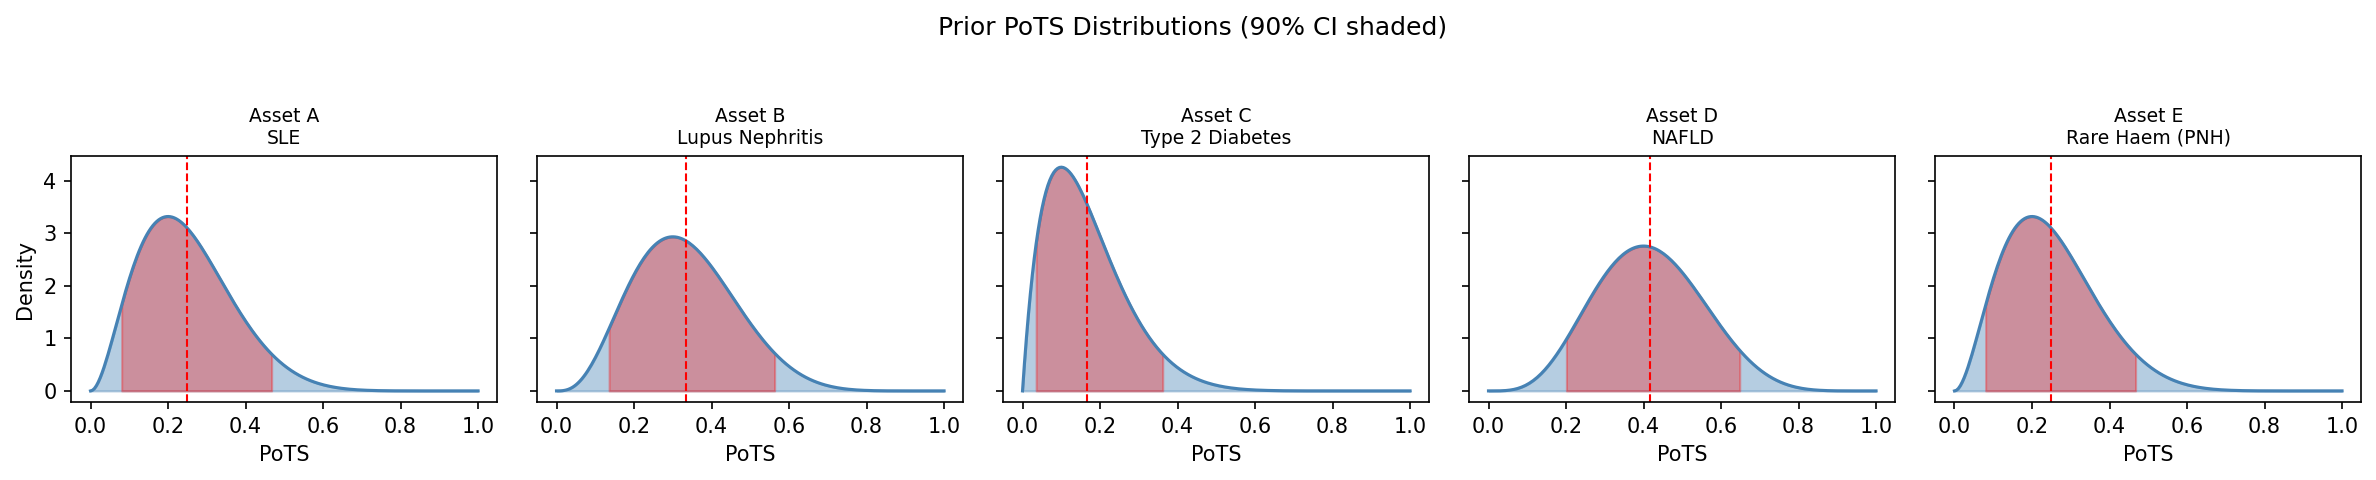

In [3]:
mean_prior, lo_prior, hi_prior = compute_pots(alpha_prior, beta_prior)
x = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, n, figsize=(16, 3), sharey=True)
for i, ax in enumerate(axes):
    pdf = beta_dist.pdf(x, alpha_prior[i], beta_prior[i])
    ax.fill_between(x, pdf, alpha=0.4, color='steelblue')
    ax.plot(x, pdf, color='steelblue')
    ax.axvline(mean_prior[i], color='red', linestyle='--', linewidth=1)
    ax.fill_between(x, pdf, where=(x >= lo_prior[i]) & (x <= hi_prior[i]),
                    alpha=0.3, color='red')
    ax.set_title(f'{assets[i]}\n{indications[i]}', fontsize=9)
    ax.set_xlabel('PoTS')
axes[0].set_ylabel('Density')
fig.suptitle('Prior PoTS Distributions (90% CI shaded)', y=1.05, fontsize=12)
fig.tight_layout()
fig.savefig('plots/prior_distributions.png', bbox_inches='tight')
plt.show()

## 3. Bayesian Updating After Interim Data

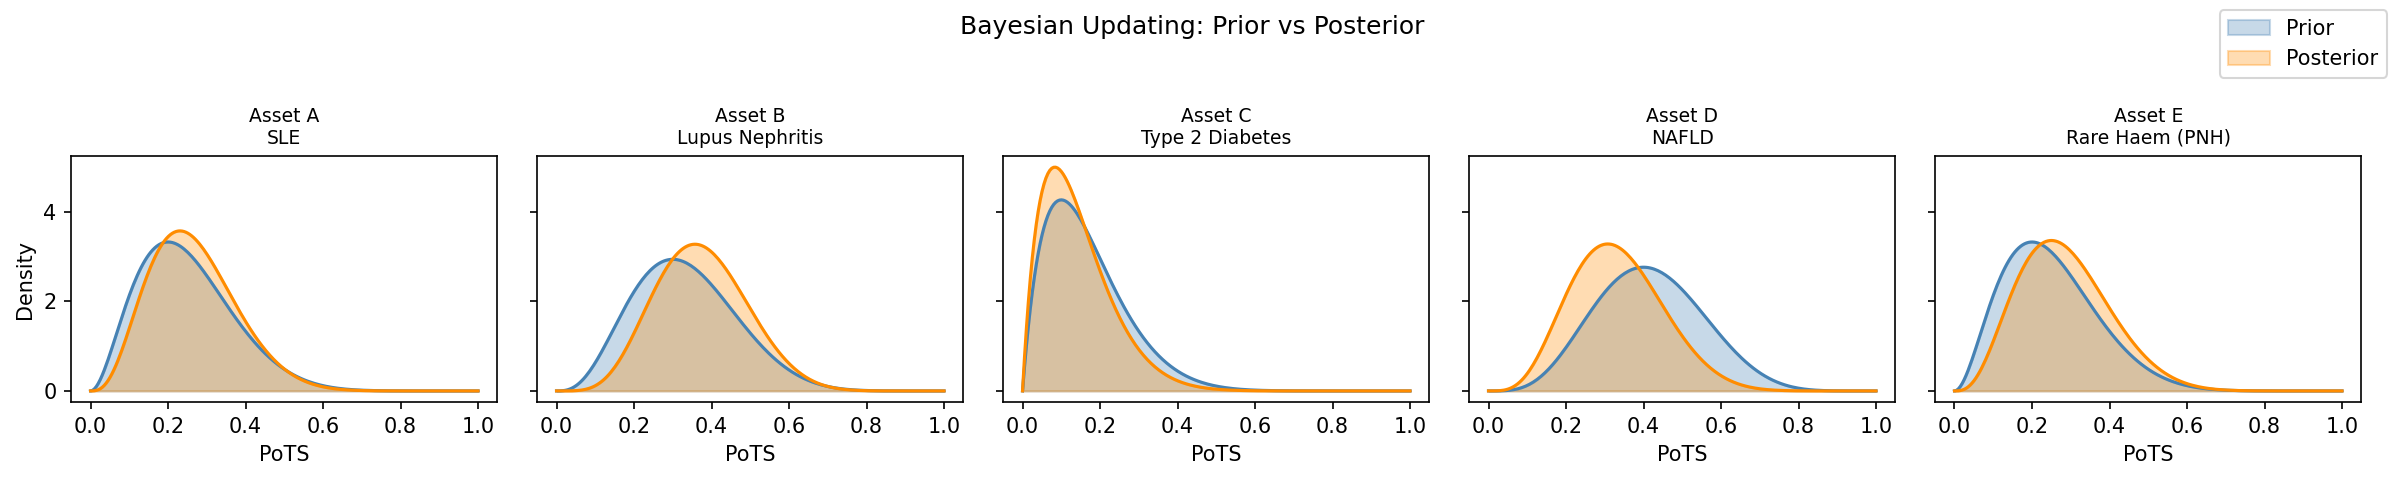

In [4]:
INTERIM = {
    'Asset A': (1, 3),
    'Asset B': (2, 4),
    'Asset C': (0, 2),
    'Asset D': (0, 3),
    'Asset E': (1, 2),
}

alpha_post, beta_post = apply_interim(alpha_prior, beta_prior, assets, INTERIM)
mean_post, lo_post, hi_post = compute_pots(alpha_post, beta_post)

fig, axes = plt.subplots(1, n, figsize=(16, 3), sharey=True)
for i, ax in enumerate(axes):
    pdf_prior = beta_dist.pdf(x, alpha_prior[i], beta_prior[i])
    pdf_post = beta_dist.pdf(x, alpha_post[i], beta_post[i])
    ax.fill_between(x, pdf_prior, alpha=0.3, color='steelblue', label='Prior' if i == 0 else None)
    ax.fill_between(x, pdf_post, alpha=0.3, color='darkorange', label='Posterior' if i == 0 else None)
    ax.plot(x, pdf_prior, color='steelblue')
    ax.plot(x, pdf_post, color='darkorange')
    ax.set_title(f'{assets[i]}\n{indications[i]}', fontsize=9)
    ax.set_xlabel('PoTS')
axes[0].set_ylabel('Density')
fig.legend(loc='upper right')
fig.suptitle('Bayesian Updating: Prior vs Posterior', y=1.05, fontsize=12)
fig.tight_layout()
fig.savefig('plots/prior_vs_posterior.png', bbox_inches='tight')
plt.show()

## 4. Correlated Failure Propagation

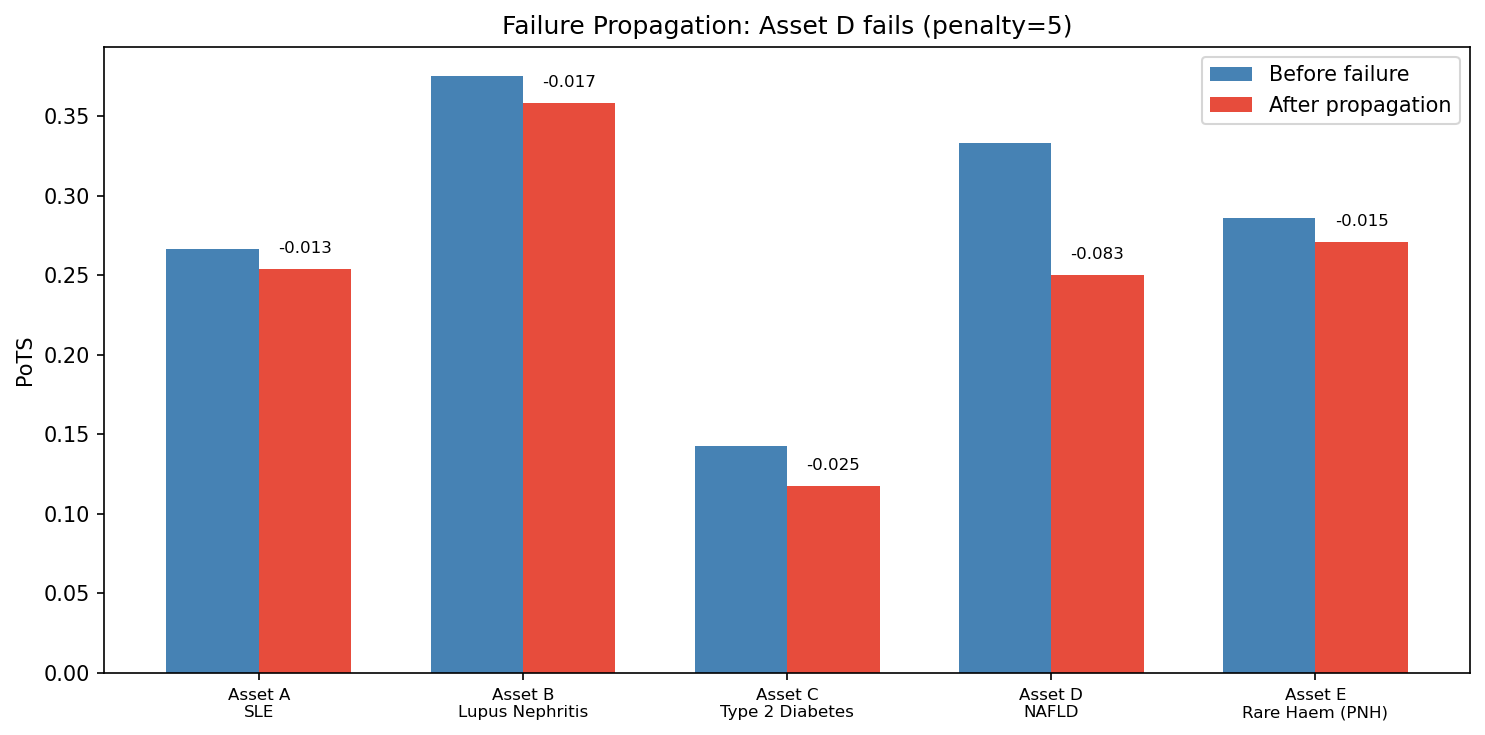

In [5]:
failed_idx = 3  # Asset D
penalty = 5
alpha_prop, beta_prop = propagate_failure(failed_idx, penalty, alpha_post, beta_post, correlation)
mean_prop, _, _ = compute_pots(alpha_prop, beta_prop)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(n)
w = 0.35
bars1 = ax.bar(x_pos - w/2, mean_post, w, label='Before failure', color='steelblue')
bars2 = ax.bar(x_pos + w/2, mean_prop, w, label='After propagation', color='#e74c3c')
for i in range(n):
    diff = mean_prop[i] - mean_post[i]
    ax.text(i + w/2, mean_prop[i] + 0.01, f'{diff:+.3f}', ha='center', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{a}\n{ind}' for a, ind in zip(assets, indications)], fontsize=8)
ax.set_ylabel('PoTS')
ax.set_title(f'Failure Propagation: {assets[failed_idx]} fails (penalty={penalty})')
ax.legend()
fig.tight_layout()
fig.savefig('plots/failure_propagation.png', bbox_inches='tight')
plt.show()

## 5. Portfolio Decisions (Phase-Dependent Thresholds)

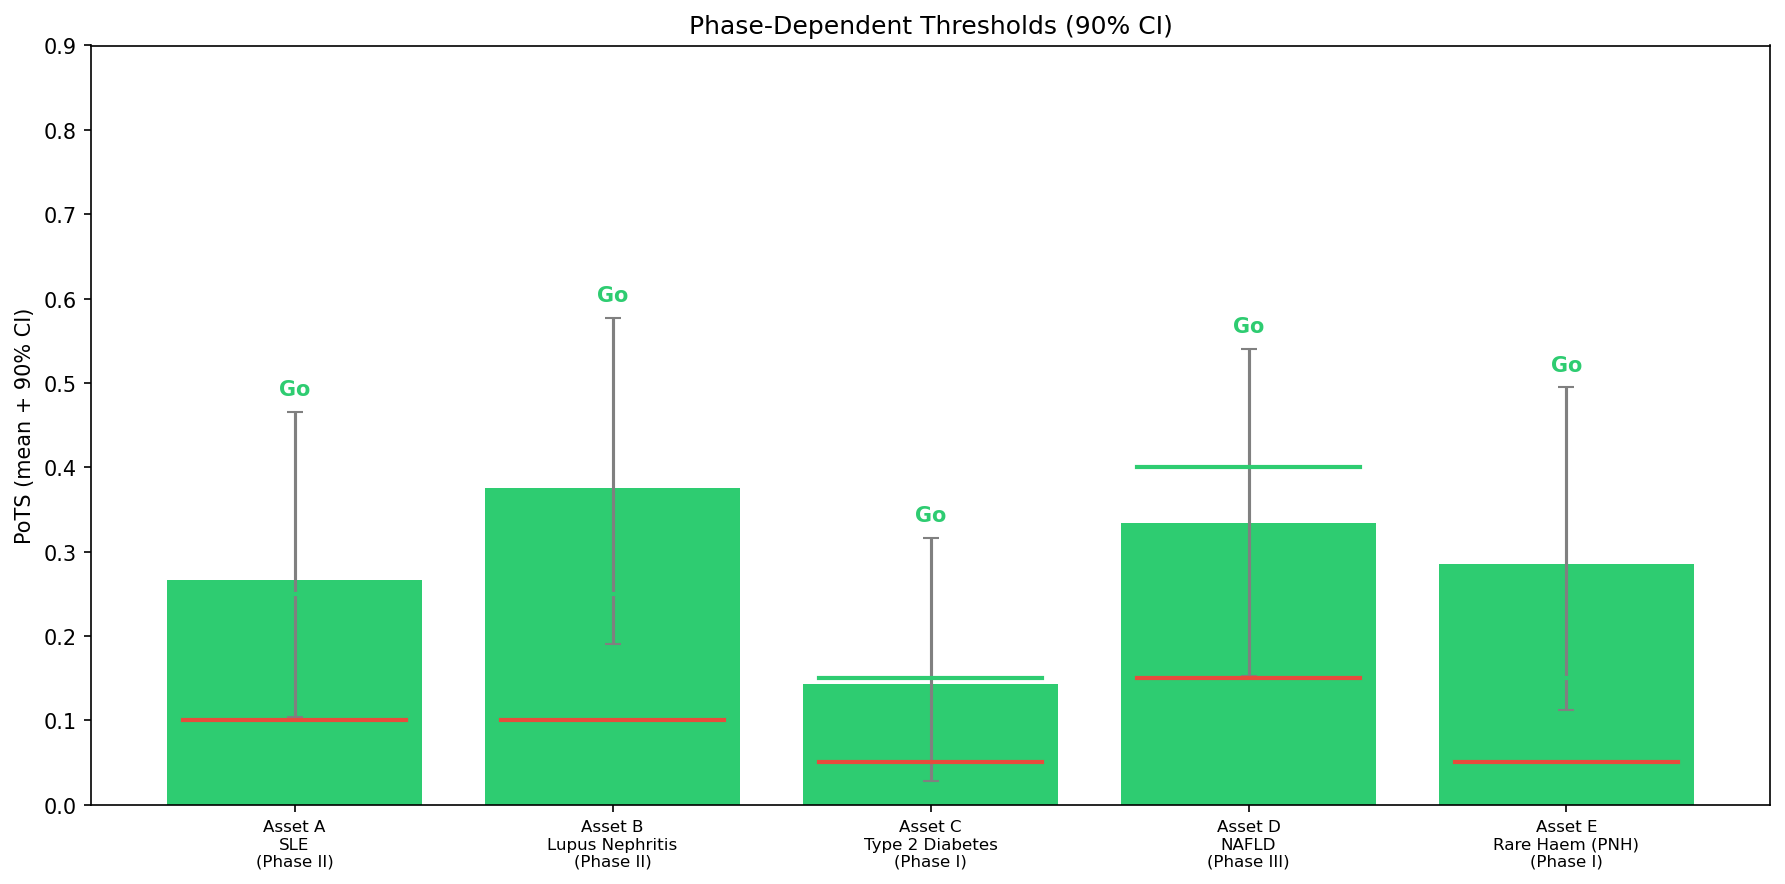

,Asset,Phase,Current Indication,PoTS,90% CI,Kill thresh,Go thresh,Decision,Suggested Repurpose,Repurpose PoTS,Reason
0,Asset A,Phase II,SLE,0.267,"[0.104, 0.466]",0.10,0.25,Go,-,-,-
1,Asset B,Phase II,Lupus Nephritis,0.375,"[0.191, 0.577]",0.10,0.25,Go,-,-,-
2,Asset C,Phase I,Type 2 Diabetes,0.143,"[0.028, 0.316]",0.05,0.15,Go,-,-,-
3,Asset D,Phase III,NAFLD,0.333,"[0.153, 0.540]",0.15,0.40,Go,-,-,-
4,Asset E,Phase I,Rare Haem (PNH),0.286,"[0.113, 0.495]",0.05,0.15,Go,-,-,-


In [6]:
thresh_scale = 1.0
decision_df = smart_decision(assets, phases, mean_post, lo_post, hi_post,
                              indications, repurpose_map, thresh_scale)

DEC_COLORS = {'Go': '#2ecc71', 'Kill': '#e74c3c', 'Repurpose': '#f39c12', 'Continue': '#3498db'}

fig, ax = plt.subplots(figsize=(12, 6))
colors = [DEC_COLORS[d] for d in decision_df['Decision']]
bars = ax.bar(range(n), mean_post, color=colors,
              yerr=[mean_post - lo_post, hi_post - mean_post],
              ecolor='grey', capsize=4)

for i in range(n):
    kt = decision_df['Kill thresh'].iloc[i]
    gt = decision_df['Go thresh'].iloc[i]
    ax.plot([i - 0.35, i + 0.35], [kt, kt], color='#e74c3c', linewidth=2)
    ax.plot([i - 0.35, i + 0.35], [gt, gt], color='#2ecc71', linewidth=2)
    ax.text(i, hi_post[i] + 0.02, decision_df['Decision'].iloc[i],
            ha='center', fontsize=10, fontweight='bold',
            color=DEC_COLORS[decision_df['Decision'].iloc[i]])

ax.set_xticks(range(n))
ax.set_xticklabels([f'{a}\n{ind}\n({ph})' for a, ind, ph in zip(assets, indications, phases)],
                    fontsize=8)
ax.set_ylabel('PoTS (mean + 90% CI)')
ax.set_ylim(0, 0.9)
ax.set_title('Phase-Dependent Thresholds (90% CI)')
fig.tight_layout()
fig.savefig('plots/portfolio_decisions.png', bbox_inches='tight')
plt.show()

display(decision_df[['Asset', 'Phase', 'Current Indication', 'PoTS', '90% CI',
                      'Kill thresh', 'Go thresh', 'Decision',
                      'Suggested Repurpose', 'Repurpose PoTS', 'Reason']])

## 6. Capital Allocation

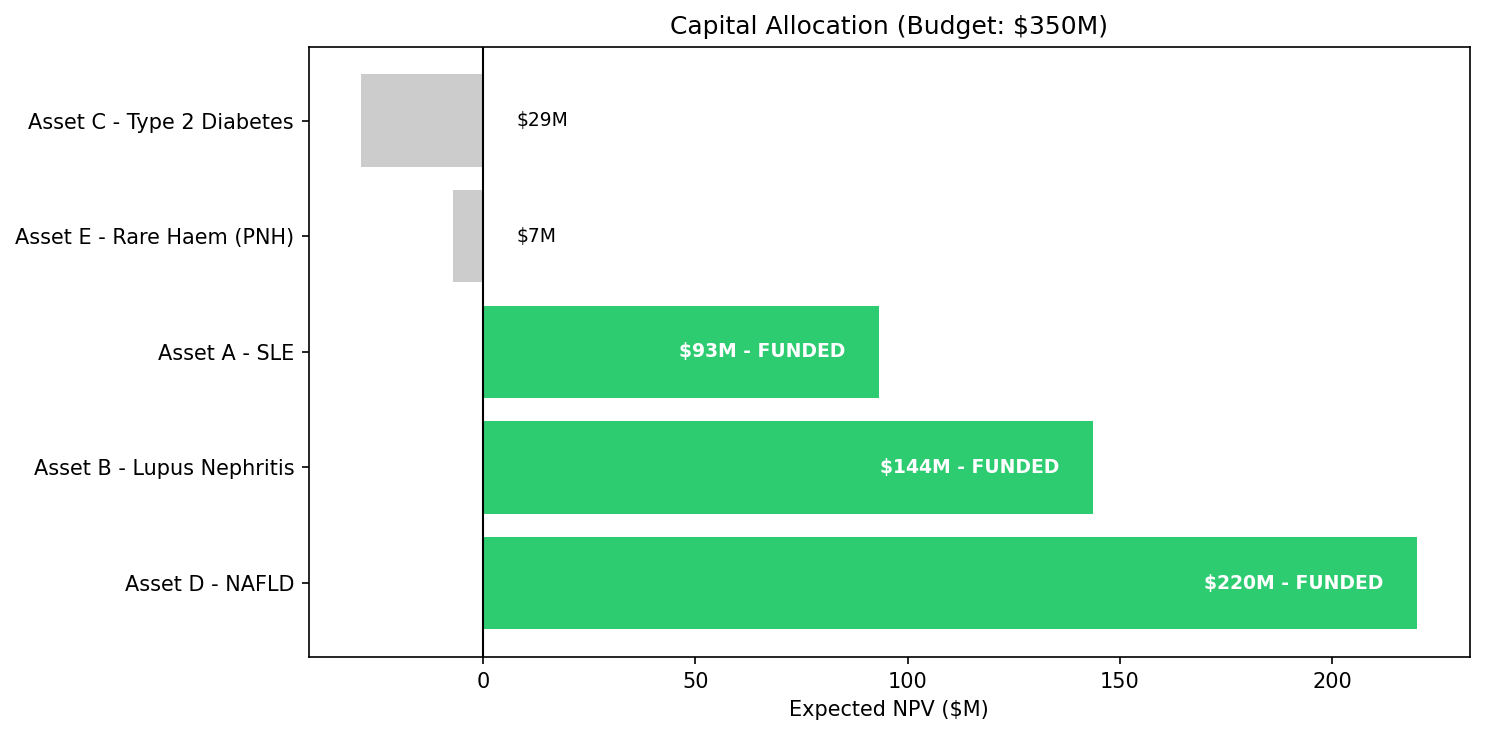

Budget: $350M | Allocated: $300M | Remaining: $50M


In [7]:
budget = 350
enpv, funded, remaining = capital_allocation(mean_post, revenue, cost, budget)

order = np.argsort(-enpv)
max_enpv = max(abs(enpv))

fig, ax = plt.subplots(figsize=(10, 5))
y_labels = [f'{assets[i]} - {indications[i]}' for i in order]
bar_colors = ['#2ecc71' if funded[i] else '#cccccc' for i in order]
ax.barh(y_labels, enpv[order], color=bar_colors)
ax.axvline(x=0, color='black', linewidth=1)

for j, i in enumerate(order):
    val = enpv[i]
    label = f'{chr(36)}{abs(val):.0f}M'
    if funded[i]:
        label += ' - FUNDED'
    if val > max_enpv * 0.4:
        ax.text(val - 8, j, label, va='center', ha='right',
                fontsize=9, fontweight='bold', color='white')
    else:
        ax.text(max(val, 0) + 8, j, label, va='center', ha='left', fontsize=9)

ax.set_xlabel('Expected NPV ({})'.format(chr(36) + 'M'))
ax.set_title(f'Capital Allocation (Budget: {chr(36)}{budget}M)')
fig.tight_layout()
fig.savefig('plots/capital_allocation.png', bbox_inches='tight')
plt.show()

print(f'Budget: {chr(36)}{budget}M | Allocated: {chr(36)}{budget - remaining:.0f}M | Remaining: {chr(36)}{remaining:.0f}M')

## 7. Monte Carlo Portfolio Simulation

Median: $250M
5th percentile: -$650M
95th percentile: $1.9B
P(positive): 62%


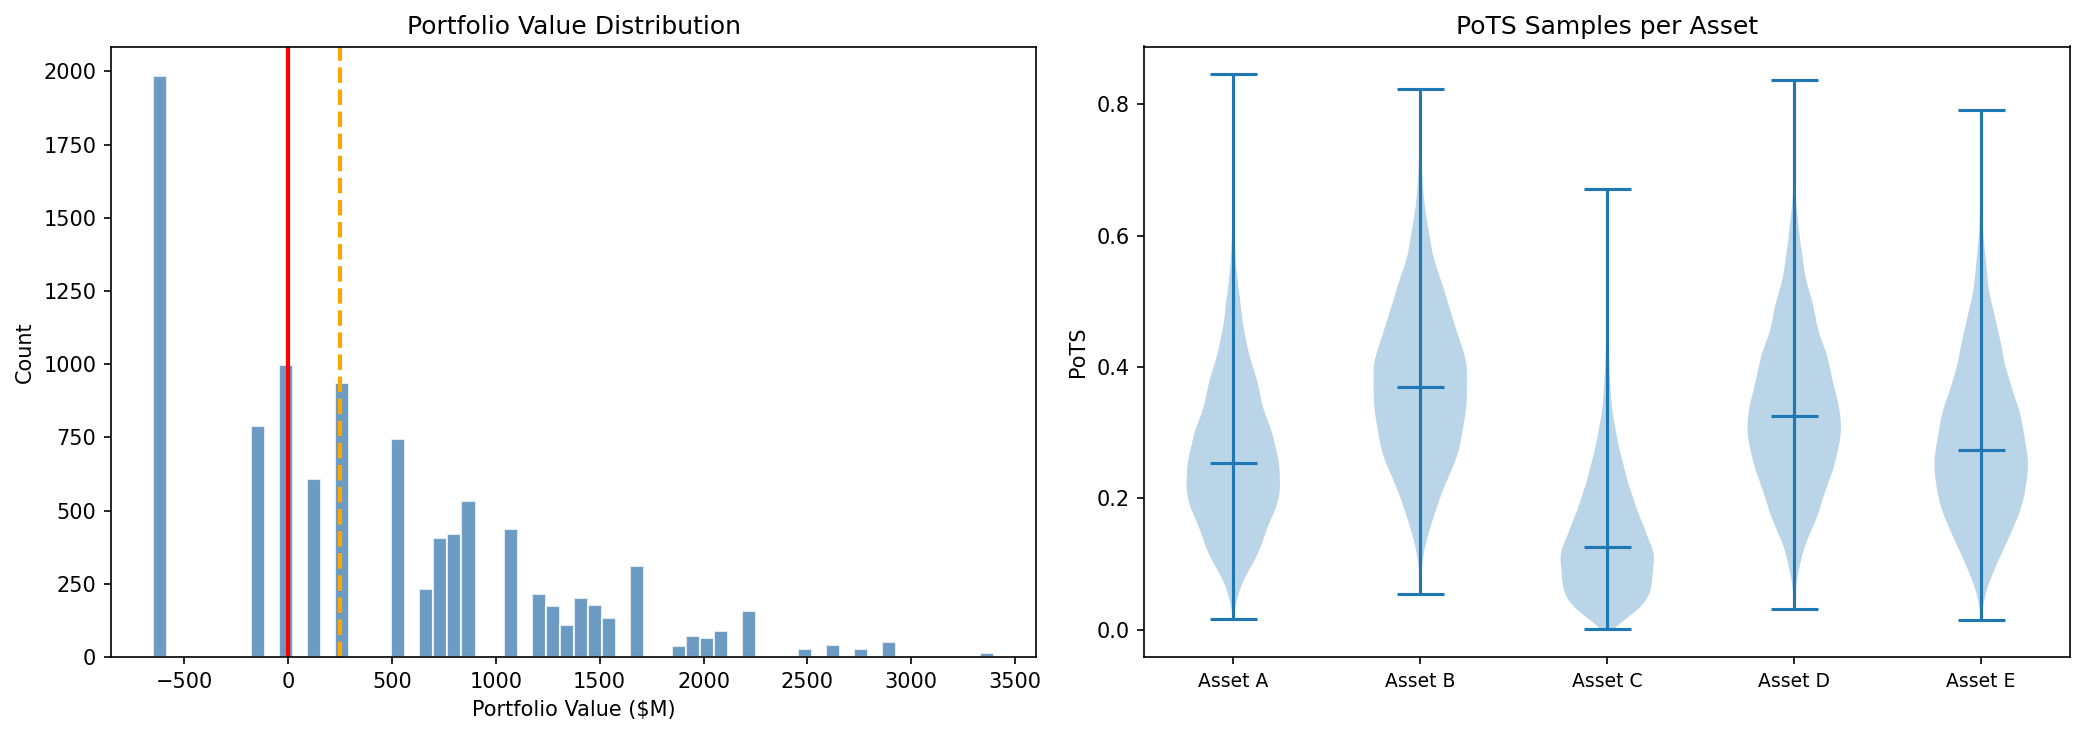

In [8]:
n_sims = 10000
pots_samples, portfolio_value = monte_carlo_portfolio(
    alpha_post, beta_post, correlation, revenue, cost, n_sims)

median_val = np.median(portfolio_value)
p5 = np.percentile(portfolio_value, 5)
p95 = np.percentile(portfolio_value, 95)

def fmt_money(v):
    neg = v < 0
    av = abs(v)
    s = f'{chr(36)}{av/1000:.1f}B' if av >= 1000 else f'{chr(36)}{av:.0f}M'
    return f'-{s}' if neg else s

print(f'Median: {fmt_money(median_val)}')
print(f'5th percentile: {fmt_money(p5)}')
print(f'95th percentile: {fmt_money(p95)}')
print(f'P(positive): {(portfolio_value > 0).mean():.0%}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(portfolio_value, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(0, color='red', linewidth=2)
ax1.axvline(median_val, color='orange', linestyle='--', linewidth=2)
ax1.set_xlabel('Portfolio Value ({})'.format(chr(36) + 'M'))
ax1.set_ylabel('Count')
ax1.set_title('Portfolio Value Distribution')

ax2.violinplot([pots_samples[:, i] for i in range(n)], positions=range(n), showmedians=True)
ax2.set_xticks(range(n))
ax2.set_xticklabels(assets, fontsize=9)
ax2.set_ylabel('PoTS')
ax2.set_title('PoTS Samples per Asset')

fig.tight_layout()
fig.savefig('plots/monte_carlo.png', bbox_inches='tight')
plt.show()

## 8. Correlation Heatmap

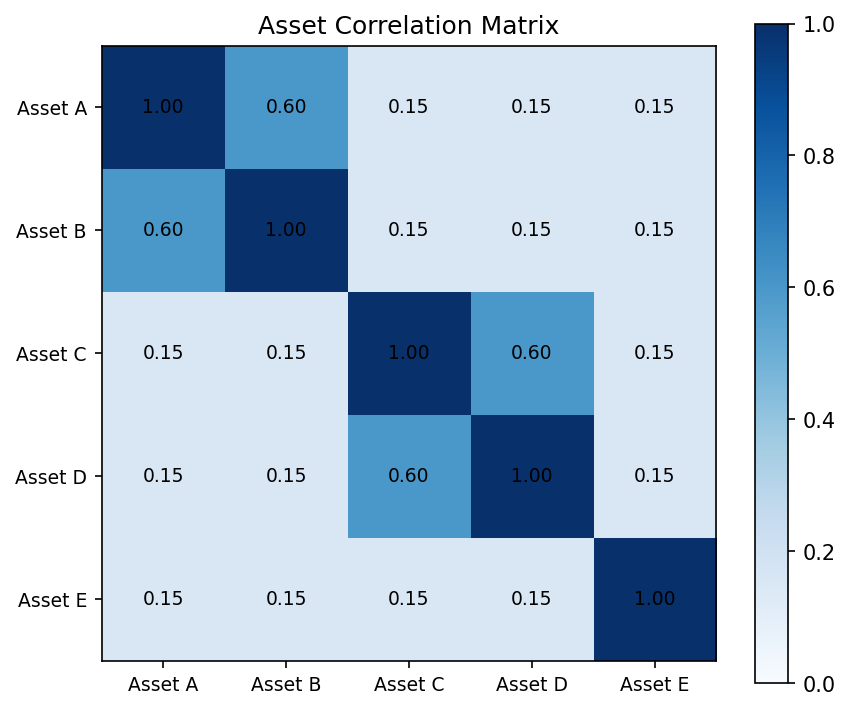

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(correlation, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(assets, fontsize=9)
ax.set_yticklabels(assets, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{correlation[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im)
ax.set_title('Asset Correlation Matrix')
fig.tight_layout()
fig.savefig('plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 9. Repurposing Landscape

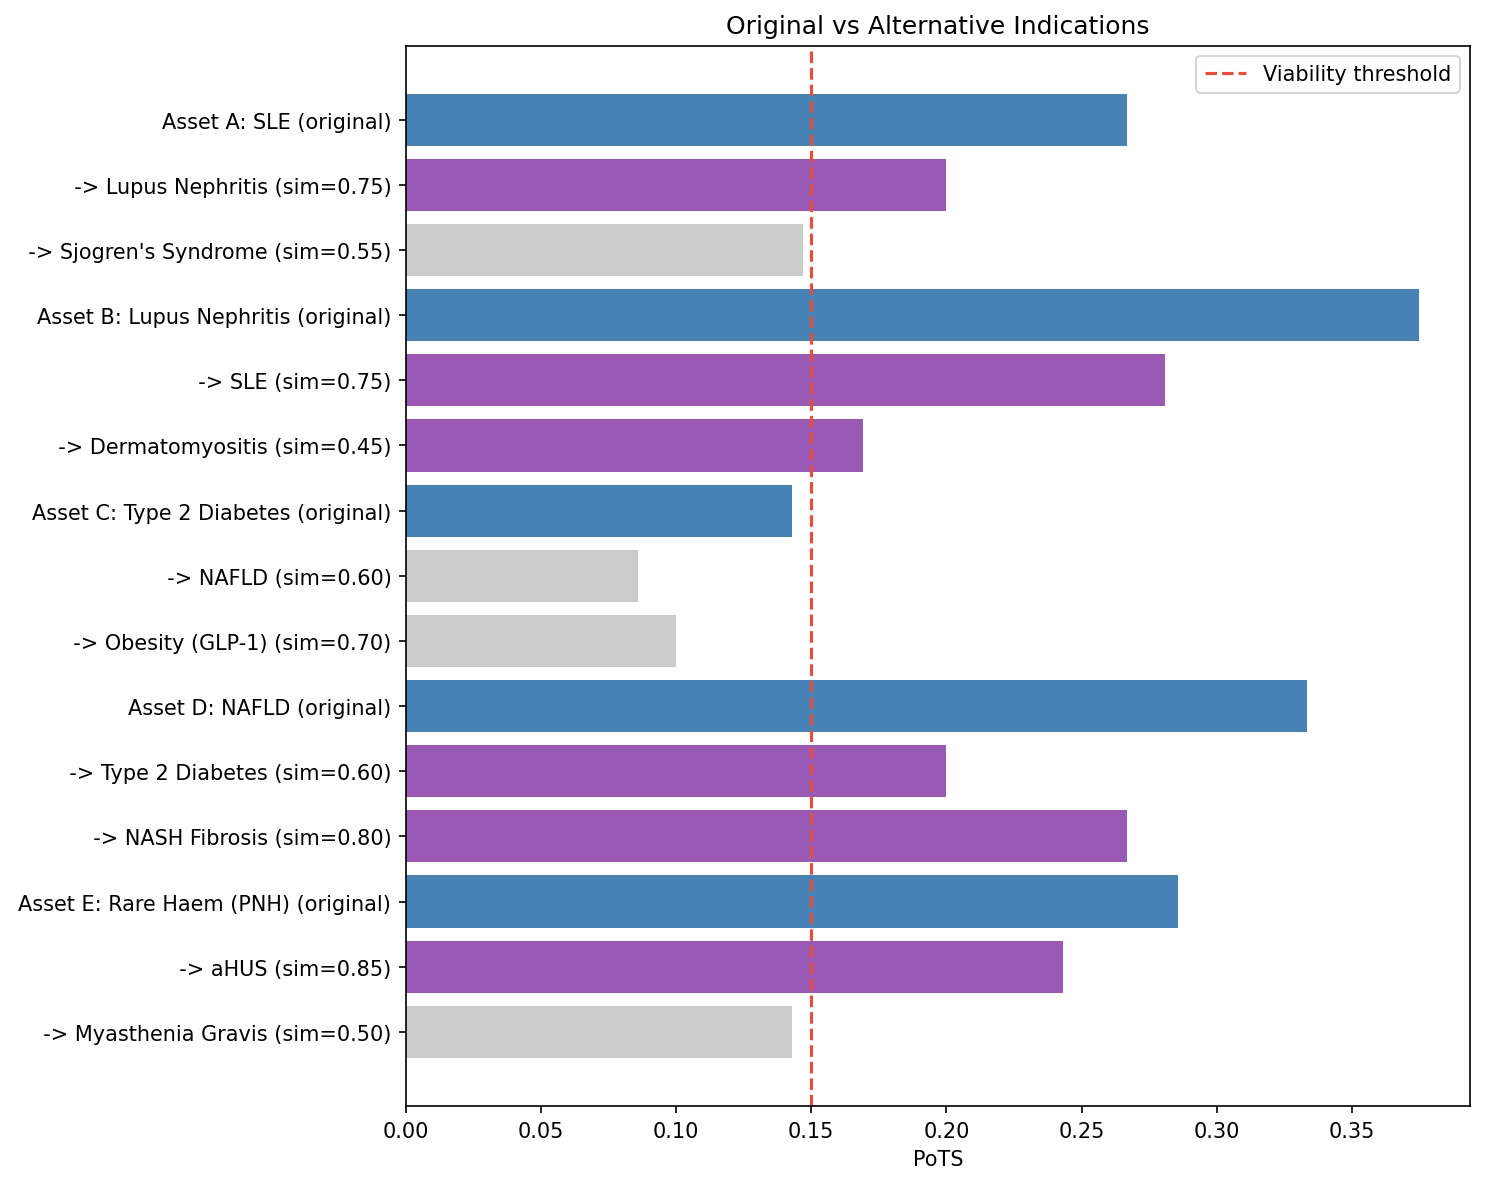

,Asset,Original Indication,Original PoTS,Alt Indication,Similarity,Repurpose PoTS,Viable,Reason
0,Asset A,SLE,0.267,Lupus Nephritis,0.75,0.200,True,Shared JAK-STAT pathway with renal inflammation
1,Asset A,SLE,0.267,Sjogren's Syndrome,0.55,0.147,False,Autoimmune overlap via B-cell activation
2,Asset B,Lupus Nephritis,0.375,SLE,0.75,0.281,True,Shared JAK-STAT pathway with systemic autoimmu...
3,Asset B,Lupus Nephritis,0.375,Dermatomyositis,0.45,0.169,True,Partial immune overlap
4,Asset C,Type 2 Diabetes,0.143,NAFLD,0.60,0.086,False,Beta-cell stress and hepatic lipid metabolism ...
5,Asset C,Type 2 Diabetes,0.143,Obesity (GLP-1),0.70,0.100,False,Direct GLP-1 receptor agonism
6,Asset D,NAFLD,0.333,Type 2 Diabetes,0.60,0.200,True,Liver-pancreas metabolic axis
7,Asset D,NAFLD,0.333,NASH Fibrosis,0.80,0.267,True,Same hepatic lipid target with fibrotic endpoint
8,Asset E,Rare Haem (PNH),0.286,aHUS,0.85,0.243,True,Same complement C5 target different disease
9,Asset E,Rare Haem (PNH),0.286,Myasthenia Gravis,0.50,0.143,False,Complement-mediated autoimmune


In [10]:
repurpose_df = build_repurpose_table(assets, indications, mean_post, repurpose_map)

y_labels_rep = []
y_values_rep = []
y_colors_rep = []
for i, asset in enumerate(assets):
    y_labels_rep.append(f'{asset}: {indications[i]} (original)')
    y_values_rep.append(mean_post[i])
    y_colors_rep.append('steelblue')
    cands = repurpose_df[repurpose_df['Asset'] == asset]
    for _, row in cands.iterrows():
        y_labels_rep.append(f"  -> {row['Alt Indication']} (sim={row['Similarity']:.2f})")
        y_values_rep.append(row['Repurpose PoTS'])
        y_colors_rep.append('#9b59b6' if row['Viable'] else '#cccccc')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(y_labels_rep, y_values_rep, color=y_colors_rep)
ax.axvline(x=0.15, color='#e74c3c', linestyle='--', label='Viability threshold')
ax.set_xlabel('PoTS')
ax.set_title('Original vs Alternative Indications')
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
fig.savefig('plots/repurpose_landscape.png', bbox_inches='tight')
plt.show()

display(repurpose_df)

## 10. Interactive Explorer (ipywidgets)

In [11]:
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox

def interactive_dashboard(thresh_scale=1.0, budget=350, use_interim=True):
    # Compute posteriors
    if use_interim:
        a_p, b_p = apply_interim(alpha_prior, beta_prior, assets, INTERIM)
    else:
        a_p, b_p = alpha_prior.copy(), beta_prior.copy()
    m, lo, hi = compute_pots(a_p, b_p)

    # Decisions
    dec_df = smart_decision(assets, phases, m, lo, hi,
                            indications, repurpose_map, thresh_scale)

    # Capital allocation
    ev, fd, rem = capital_allocation(m, revenue, cost, budget)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Decision plot
    colors = [DEC_COLORS[d] for d in dec_df['Decision']]
    ax1.bar(range(n), m, color=colors,
            yerr=[m - lo, hi - m], ecolor='grey', capsize=4)
    for i in range(n):
        kt = dec_df['Kill thresh'].iloc[i]
        gt = dec_df['Go thresh'].iloc[i]
        ax1.plot([i - 0.35, i + 0.35], [kt, kt], color='#e74c3c', linewidth=2)
        ax1.plot([i - 0.35, i + 0.35], [gt, gt], color='#2ecc71', linewidth=2)
        ax1.text(i, hi[i] + 0.02, dec_df['Decision'].iloc[i],
                 ha='center', fontsize=10, fontweight='bold',
                 color=DEC_COLORS[dec_df['Decision'].iloc[i]])
    ax1.set_xticks(range(n))
    ax1.set_xticklabels([f'{a}\n({ph})' for a, ph in zip(assets, phases)], fontsize=8)
    ax1.set_ylabel('PoTS')
    ax1.set_ylim(0, 0.9)
    ax1.set_title('Decisions')

    # Capital allocation plot
    order = np.argsort(-ev)
    y_lab = [f'{assets[i]}' for i in order]
    bar_col = ['#2ecc71' if fd[i] else '#cccccc' for i in order]
    ax2.barh(y_lab, ev[order], color=bar_col)
    ax2.axvline(x=0, color='black', linewidth=1)
    ax2.set_xlabel('eNPV ({})'.format(chr(36) + 'M'))
    ax2.set_title(f'Capital Allocation ({chr(36)}{budget}M budget, {chr(36)}{rem:.0f}M remaining)')

    fig.tight_layout()
    plt.show()

interact(interactive_dashboard,
         thresh_scale=FloatSlider(min=0.5, max=2.0, step=0.1, value=1.0, description='Thresh scale'),
         budget=IntSlider(min=100, max=800, step=50, value=350, description='Budget ($M)'),
         use_interim=Checkbox(value=True, description='Interim data'));

interactive(children=(FloatSlider(value=1.0, description='Thresh scale', max=2.0, min=0.5), IntSlider(value=35…